In [142]:
import numpy as np
import pandas as pd
import seaborn as sns 
from seaborn import heatmap
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

In [143]:
boston = pd.read_csv("HousingData_filled_numbers.csv")

In [144]:
print(boston.keys())

Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT', 'PRICE'],
      dtype='object')


In [145]:
print(boston.columns)

Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT', 'PRICE'],
      dtype='object')


In [146]:
boston.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.980000,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.140000,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.030000,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.940000,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,12.715432,36.2


In [147]:
boston.shape

(506, 14)

In [148]:
boston.dtypes

CRIM       float64
ZN         float64
INDUS      float64
CHAS       float64
NOX        float64
RM         float64
AGE        float64
DIS        float64
RAD          int64
TAX          int64
PTRATIO    float64
B          float64
LSTAT      float64
PRICE      float64
dtype: object

In [149]:
boston.isnull().sum()

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
PRICE      0
dtype: int64

In [150]:
corr = boston.corr()

In [151]:
corr

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
CRIM,1.000000,-0.182930,0.391161,-0.052223,0.410377,-0.215434,0.344934,-0.366523,0.608886,0.566528,0.273384,-0.370163,0.434044,-0.379695
ZN,-0.182930,1.000000,-0.513336,-0.036147,-0.502287,0.316550,-0.541274,0.638388,-0.306316,-0.308334,-0.403085,0.167431,-0.407549,0.365943
INDUS,0.391161,-0.513336,1.000000,0.058035,0.740965,-0.381457,0.614592,-0.699639,0.593176,0.716062,0.384806,-0.354597,0.567354,-0.478657
CHAS,-0.052223,-0.036147,0.058035,1.000000,0.073286,0.102284,0.075206,-0.091680,0.001425,-0.031483,-0.109310,0.050055,-0.046166,0.179882
NOX,0.410377,-0.502287,0.740965,0.073286,1.000000,-0.302188,0.711461,-0.769230,0.611441,0.668023,0.188933,-0.380051,0.572379,-0.427321
RM,-0.215434,0.316550,-0.381457,0.102284,-0.302188,1.000000,-0.241351,0.205246,-0.209847,-0.292048,-0.355501,0.128069,-0.602962,0.695360
AGE,0.344934,-0.541274,0.614592,0.075206,0.711461,-0.241351,1.000000,-0.724353,0.449989,0.500589,0.262723,-0.265282,0.574893,-0.380223
DIS,-0.366523,0.638388,-0.699639,-0.091680,-0.769230,0.205246,-0.724353,1.000000,-0.494588,-0.534432,-0.232471,0.291512,-0.483429,0.249929
RAD,0.608886,-0.306316,0.593176,0.001425,0.611441,-0.209847,0.449989,-0.494588,1.000000,0.910228,0.464741,-0.444413,0.468440,-0.381626
TAX,0.566528,-0.308334,0.716062,-0.031483,0.668023,-0.292048,0.500589,-0.534432,0.910228,1.000000,0.460853,-0.441808,0.524545,-0.468536


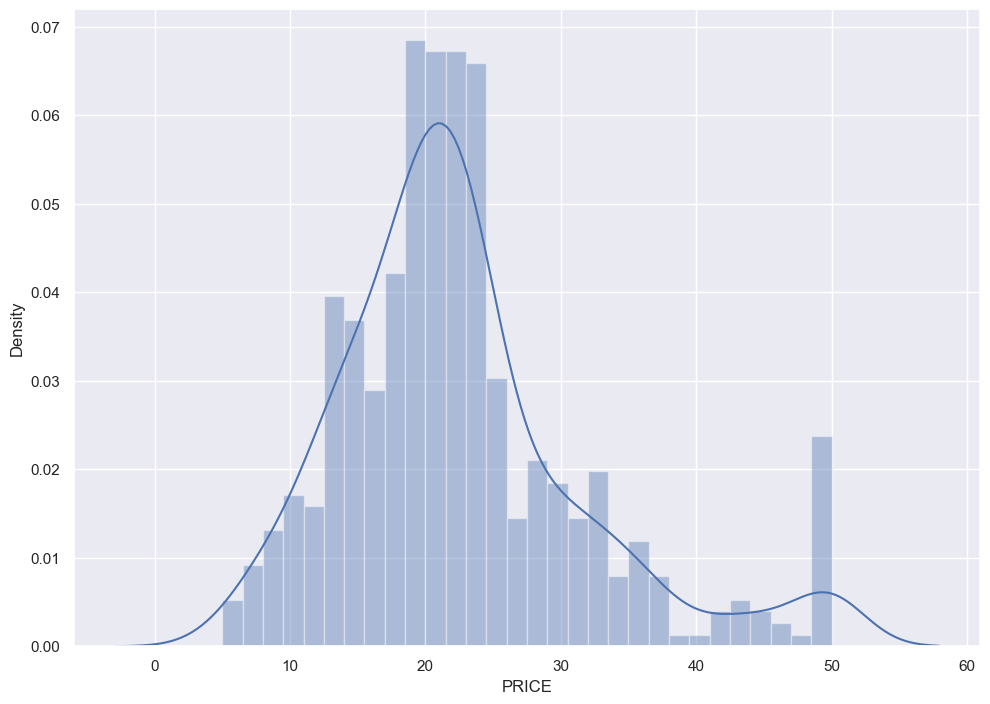

In [152]:
sns.set(rc={'figure.figsize':(11.7,8.27)})
sns.distplot(boston['PRICE'], bins=30)
plt.show()

<Axes: >

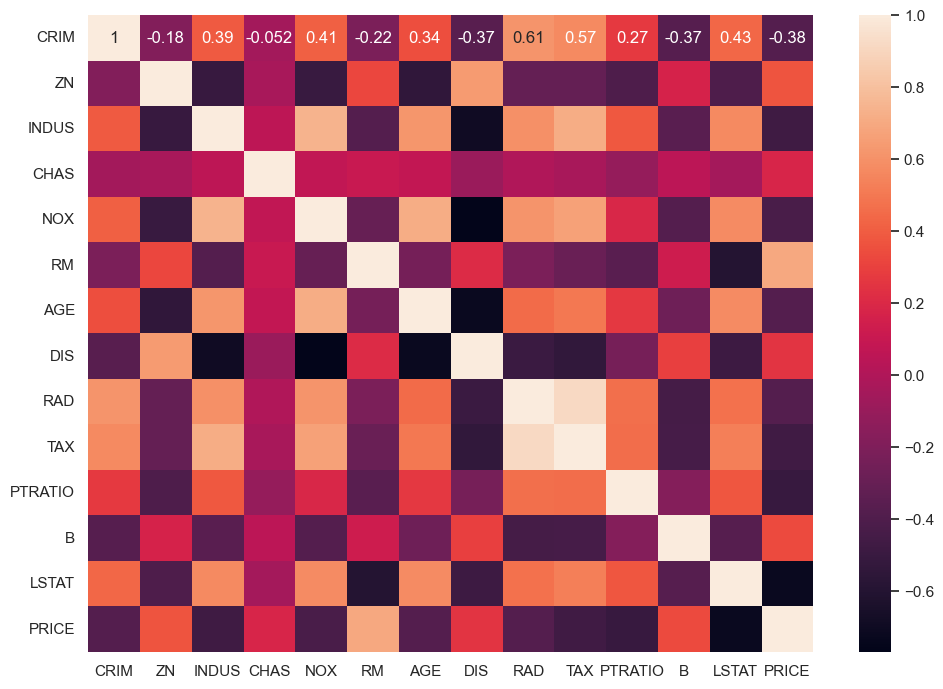

In [153]:
sns.heatmap(corr, annot=True)

In [156]:
X = boston.drop(['PRICE'] , axis = 1)
y = boston['PRICE']

In [158]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

In [159]:
X_train.shape

(379, 13)

In [160]:
X_test.shape

(127, 13)

In [161]:
y_train.shape

(379,)

In [162]:
y_test.shape

(127,)

In [163]:
linearReg = LinearRegression()
linearReg.fit(X_train, y_train)
y_train_predict = linearReg.predict(X_train)

In [164]:
y_train_predict

array([33.68390738, 20.50481485, 38.94209463, 14.62783164, 25.93671766,
       17.71754045, 20.97974467, 10.34959129, 20.13722444, 22.63743938,
       31.56763308, 31.43084216, 15.6779981 , 17.10602005, 28.53691702,
       24.53484718, 17.40259275,  6.68123308, 25.94565443, 23.02135111,
       20.42120985, 13.84131637, 41.02822387, 16.04123281, 17.85656915,
       25.35742894, 23.55187035, 22.28630135, 21.27882797, 16.56449851,
       22.17894967, 29.34551538,  6.70367594, 24.85370438, 17.02662851,
       21.71183982, 25.15734247, 27.52485174, 21.31046416, 41.36683261,
       18.61950878, 15.27638025, 19.28621068, 16.94623418, 22.89377268,
       23.39573965, 32.96604169, 22.40478157, 20.87727156, 25.29465338,
       31.56028813, 33.13515394, 28.30742422,  9.05031988,  5.81693448,
       17.9327296 , 20.02148921, 31.64993438, 33.68858969, 15.6303533 ,
        4.61977889, 32.30280244, 21.71148756, 18.66221934, 25.53016139,
       18.6417365 , 18.44839417, 11.73860167, 31.13529665, 24.95

In [165]:
linearReg.coef_

array([-1.25503627e-01,  2.64914896e-02, -2.08487182e-02,  3.24816811e+00,
       -1.50708382e+01,  4.70350159e+00, -2.30073744e-02, -1.46671180e+00,
        2.14419008e-01, -8.34110486e-03, -8.95928457e-01,  1.30515512e-02,
       -4.46415149e-01])

In [166]:
linearReg.intercept_

27.451863212802603

In [167]:
y_test_predict = linearReg.predict(X_test)

In [168]:
y_test_predict

array([29.1000167 , 36.50596936, 14.75387304, 25.3326485 , 18.53212239,
       22.99322946, 18.13561219, 14.57509445, 22.12297534, 20.86176246,
       24.95939006, 18.79585011, -6.45185246, 21.8466478 , 19.02802909,
       25.50483268, 19.50568718,  5.96531148, 40.86801371, 17.24115276,
       24.92485526, 30.24926918, 11.62389661, 22.90718778, 17.34005193,
       15.02615496, 21.26148277, 14.1819866 , 22.91788454, 19.49374922,
       22.38090131, 25.2929711 , 25.68509566, 16.84387255, 16.35255784,
       16.76295306, 31.12717074, 20.35619392, 24.3524566 , 22.81159137,
       14.53320936, 32.07254578, 42.81727647, 17.79302817, 27.54617302,
       16.46779424, 14.07697601, 26.38690579, 19.81356103, 30.19299604,
       21.04645118, 33.7290939 , 16.27125694, 26.3702921 , 39.78425159,
       22.30903672, 18.69951088, 32.69944318, 25.4153868 , 13.06580763,
       22.88378452, 30.74201416, 31.49926477, 16.36079803, 20.63390123,
       16.96154273, 20.13499765, 26.23885133, 30.90048952, 11.18

In [169]:
R2 = r2_score(y_test,y_test_predict)
MAE = mean_absolute_error(y_test,y_test_predict)
MSE = mean_squared_error(y_test,y_test_predict)
RMSE = np.sqrt(MSE)
print("R2", R2)
print("MAE", MAE)
print("MSE", MSE)
print("RMSE", RMSE)

R2 0.6800331878713536
MAE 3.00887511231172
MSE 22.406361917537076
RMSE 4.733535878974308


Text(0, 0.5, 'Predicted Prices')

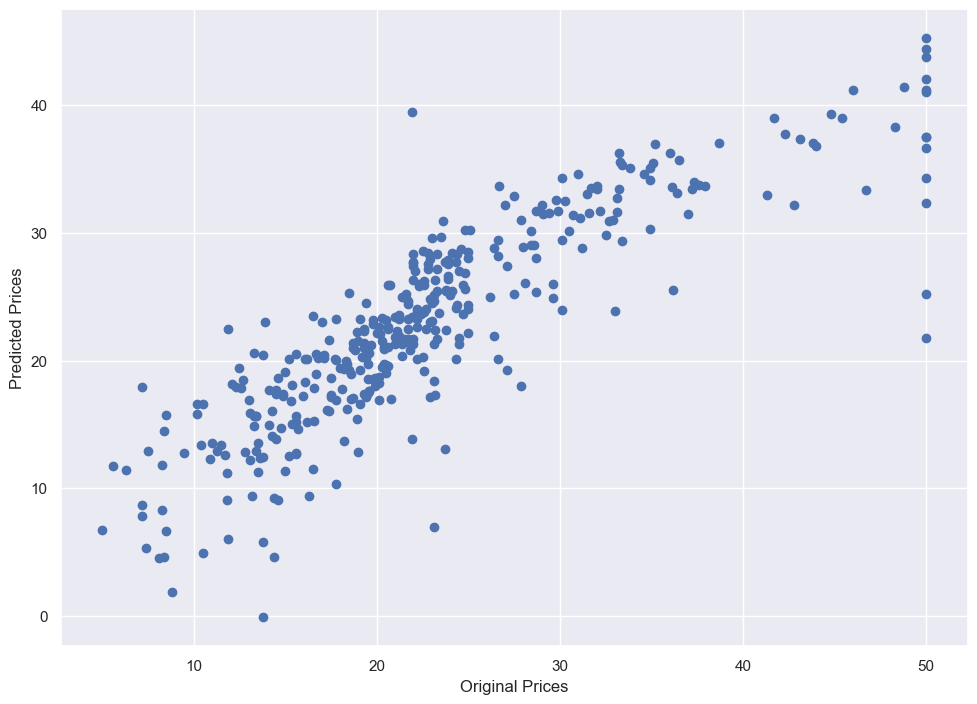

In [170]:
plt.scatter(y_train, y_train_predict)
plt.xlabel("Original Prices")
plt.ylabel("Predicted Prices")

Text(0, 0.5, 'Predicted Prices')

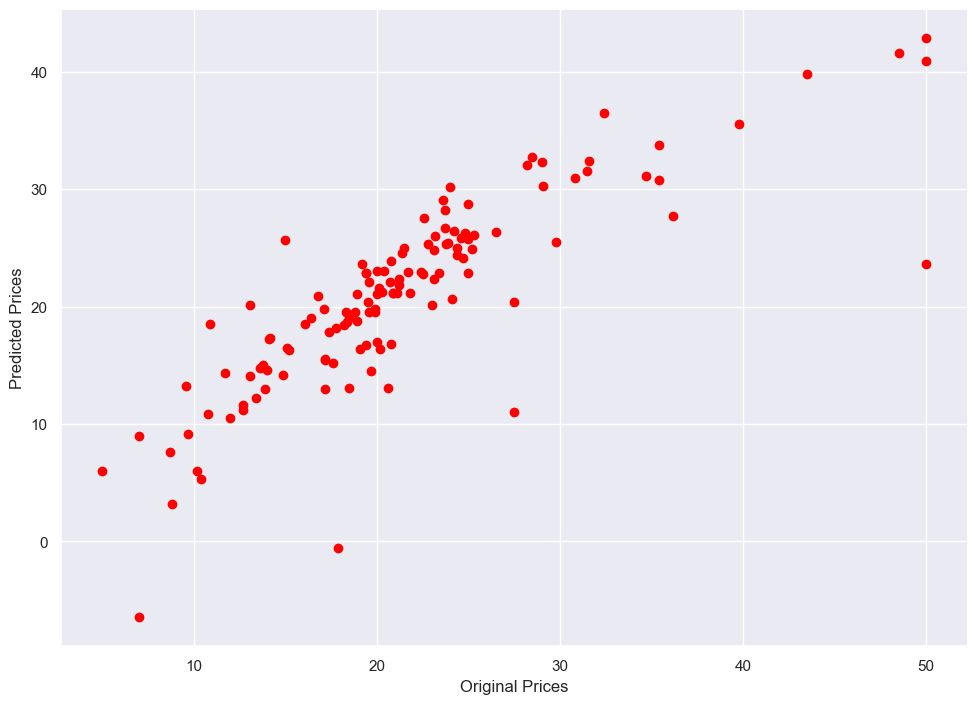

In [171]:
plt.scatter(y_test, y_test_predict,color='red')
plt.xlabel("Original Prices")
plt.ylabel("Predicted Prices")

In [172]:
linearReg.score(X_test,y_test)

0.6800331878713536